## Imports

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import numpy as np


## Load Data

In [2]:
df = pd.read_csv("../data/mar_apr_may_spring_dataset.csv")

In [3]:
df.head()

,s_date,s_hour,day_of_week,week_of_month,weekend_or_weekday_sdate,is_holiday,time_of_day,peak_off_peak,start_station_number,longitude,...,dist_to_nearest_library,dist_to_nearest_cinema,dist_to_nearest_supermarket,dist_to_nearest_station,dist_to_nearest_platform,dist_to_nearest_stop_position,dist_to_nearest_railway_station,dist_to_nearest_bus_stop,month,count
0,2023-03-05,23,6,1,weekend,False,night,0,22180,-0.092940,...,362.017443,1147.727066,148.273179,321.503088,119.762530,119.762530,321.503088,119.762530,1,1
1,2023-03-05,23,6,1,weekend,False,night,0,3455,-0.113856,...,444.935826,817.903121,1047.439097,146.125704,124.324872,111.913501,146.125704,124.324872,1,0
2,2023-03-05,23,6,1,weekend,False,night,0,1080,-0.082990,...,934.875850,1111.170005,530.033281,253.789958,134.798921,134.798921,253.789958,134.798921,1,1
3,2023-03-05,23,6,1,weekend,False,night,0,963,-0.100186,...,770.987861,653.631098,25.929076,536.520850,127.637853,127.637853,536.520850,127.637853,1,1
4,2023-03-05,23,6,1,weekend,False,night,0,200253,-0.091402,...,456.703128,533.949383,528.480504,269.759617,161.655090,161.655090,269.759617,161.655090,1,1


In [4]:
print("Number Of Stations: {0}".format(len(df["start_station_number"].unique())))

Number Of Stations: 100


In [5]:
num = 1

print("All Column Names: ")
for column in df.columns:
    print(f"\t{num}) " + column)
    num += 1

All Column Names: 
	1) s_date
	2) s_hour
	3) day_of_week
	4) week_of_month
	5) weekend_or_weekday_sdate
	6) is_holiday
	7) time_of_day
	8) peak_off_peak
	9) start_station_number
	10) longitude
	11) latitude
	12) cafe_count_5min_walk
	13) atm_count_5min_walk
	14) pub_count_5min_walk
	15) school_count_5min_walk
	16) university_count_5min_walk
	17) college_count_5min_walk
	18) bank_count_5min_walk
	19) post_office_count_5min_walk
	20) library_count_5min_walk
	21) cinema_count_5min_walk
	22) supermarket_count_5min_walk
	23) station_count_5min_walk
	24) platform_count_5min_walk
	25) stop_position_count_5min_walk
	26) railway_station_count_5min_walk
	27) highway_bus_stop_count_5min_walk
	28) dist_to_nearest_cafe
	29) dist_to_nearest_atm
	30) dist_to_nearest_pub
	31) dist_to_nearest_school
	32) dist_to_nearest_university
	33) dist_to_nearest_college
	34) dist_to_nearest_bank
	35) dist_to_nearest_post_office
	36) dist_to_nearest_library
	37) dist_to_nearest_cinema
	38) dist_to_nearest_supermar

In [6]:
# len(df["latitude"].unique())
print( f"Number of Rows with N/A Values: {len(df[df.isna().any(axis=1)])}")

Number of Rows with N/A Values: 0


In [7]:
missing_lat_stations = df[df['latitude'].isnull()]['start_station_number'].tolist()

print("Station numbers with missing latitude:", missing_lat_stations)

Station numbers with missing latitude: []


In [8]:
print(df.info()) 
print(df.describe())  
print(df.nunique()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194400 entries, 0 to 194399
Data columns (total 45 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   s_date                            194400 non-null  object 
 1   s_hour                            194400 non-null  int64  
 2   day_of_week                       194400 non-null  int64  
 3   week_of_month                     194400 non-null  int64  
 4   weekend_or_weekday_sdate          194400 non-null  object 
 5   is_holiday                        194400 non-null  bool   
 6   time_of_day                       194400 non-null  object 
 7   peak_off_peak                     194400 non-null  int64  
 8   start_station_number              194400 non-null  int64  
 9   longitude                         194400 non-null  float64
 10  latitude                          194400 non-null  float64
 11  cafe_count_5min_walk              194400 non-null  i

In [9]:
df['log_count'] = np.log10(df['count']) # Log Transformed Y

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


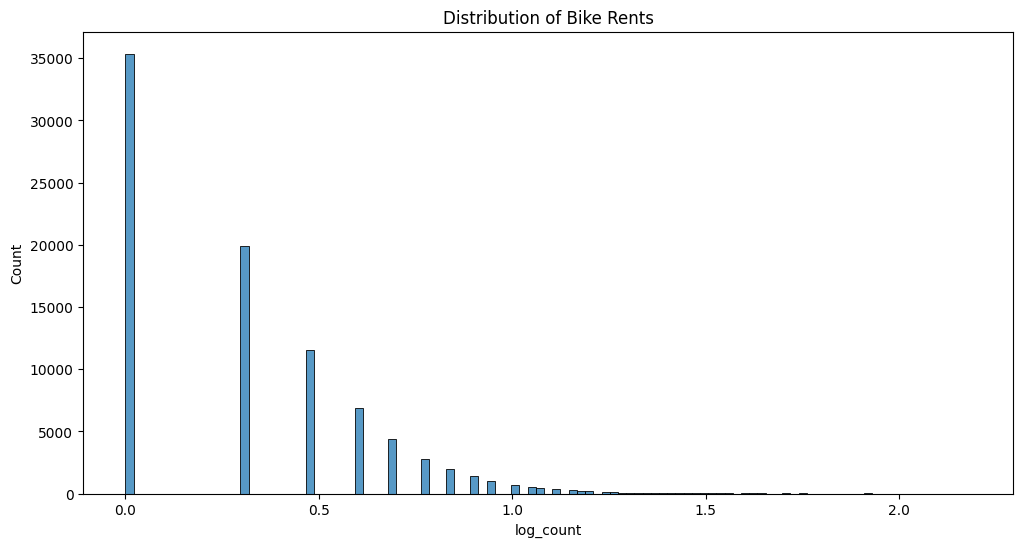

In [10]:


plt.figure(figsize=(12,6))
sns.histplot(df['log_count'])
plt.title('Distribution of Bike Rents')
plt.show()

### Demand For Each Day Of The Week

   day_of_week  count
0            0  34537
1            1  46785
2            2  51591
3            3  50501
4            4  37825
5            5  25982
6            6  23858


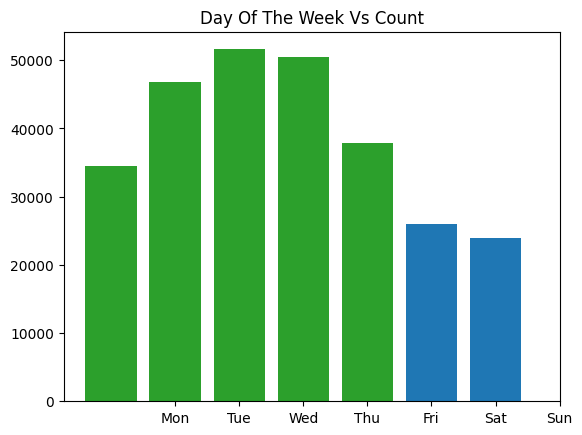

In [11]:
temp_df = df.groupby("day_of_week")["count"].sum().reset_index()
print(temp_df)

plt.bar(x = "day_of_week", height="count", data=temp_df, color=["#2ca02c", "#2ca02c", "#2ca02c", "#2ca02c","#2ca02c","#1f77b4", "#1f77b4"])
plt.title("day of the week vs count".title())
plt.xticks(labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], ticks=(1,2,3,4,5,6,7))
plt.show()

### Demand For Day Of The Week And Week Of The Month

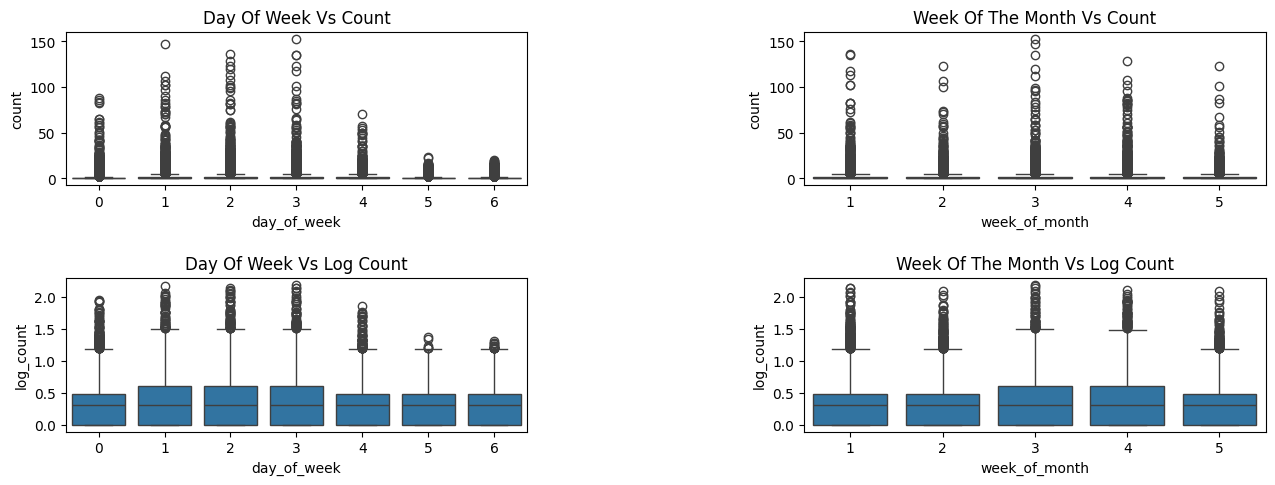

In [12]:
fig, ax = plt.subplots(2,2, figsize=(15,5))
sns.boxplot(x='day_of_week', y='count', data=df, ax=ax[0][0])
sns.boxplot(x='week_of_month', y='count', data=df, ax=ax[0][1])
sns.boxplot(x='day_of_week', y='log_count', data=df, ax=ax[1][0])
sns.boxplot(x='week_of_month', y='log_count', data=df, ax=ax[1][1])

ax[0][0].set_title('day of week vs count'.title())
ax[0][1].set_title('week of the month vs count'.title())
ax[1][0].set_title('day of week vs log count'.title())
ax[1][1].set_title('week of the month vs log count'.title())

plt.subplots_adjust(
    left=0.1,    
    right=0.9,   
    bottom=0.1,  
    top=0.9,     
    wspace=0.6,  
    hspace=0.6   
)

plt.show()

### Demand For Weekdays and Weekends

  weekend_or_weekday_sdate   count
0                  weekday  221239
1                  weekend   49840


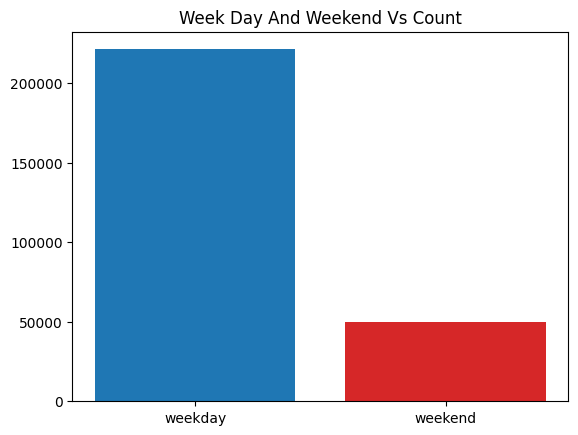

In [13]:
temp_df = df.groupby("weekend_or_weekday_sdate")["count"].sum().reset_index()

print(temp_df)

plt.bar(x = "weekend_or_weekday_sdate", height="count", data=temp_df, color=["#1f77b4","#d62728"])
plt.xticks(ticks=(0,1))
plt.title("week day and weekend vs count".title())
plt.show()


### Demand For Time Of The Day

  time_of_day   count
0         day  108924
1     evening   72221
2     morning   71739
3       night   18195


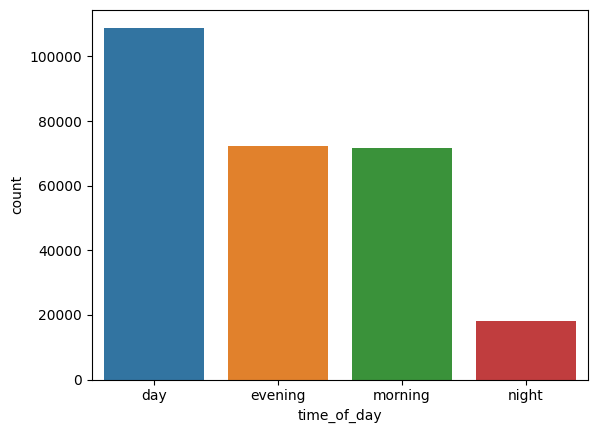

In [14]:
temp_df = df.groupby("time_of_day")["count"].sum().reset_index()
print(temp_df)

sns.barplot(x = "time_of_day", y="count", data=temp_df, hue="time_of_day")

plt.show()


### Demand For Peak And Off Peak Times

                count
peak_off_peak        
0              235251
1               35828


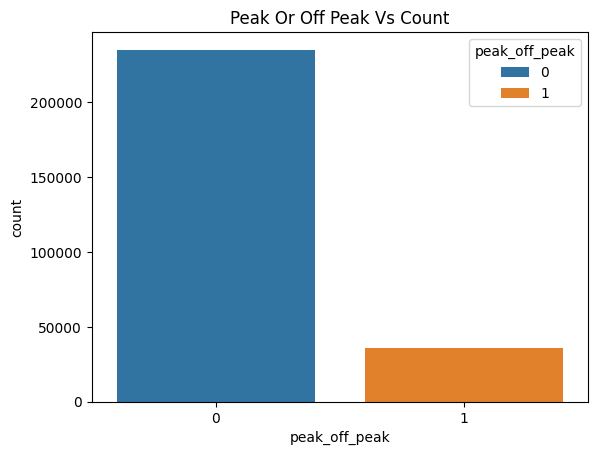

In [15]:
temp_df = df.groupby("peak_off_peak").agg({"count":"sum"})

print(temp_df)
sns.barplot(x='peak_off_peak', y='count', data=temp_df, hue="peak_off_peak")
plt.title("peak or off peak vs count".title())
plt.show()

### Demand For Each Hour

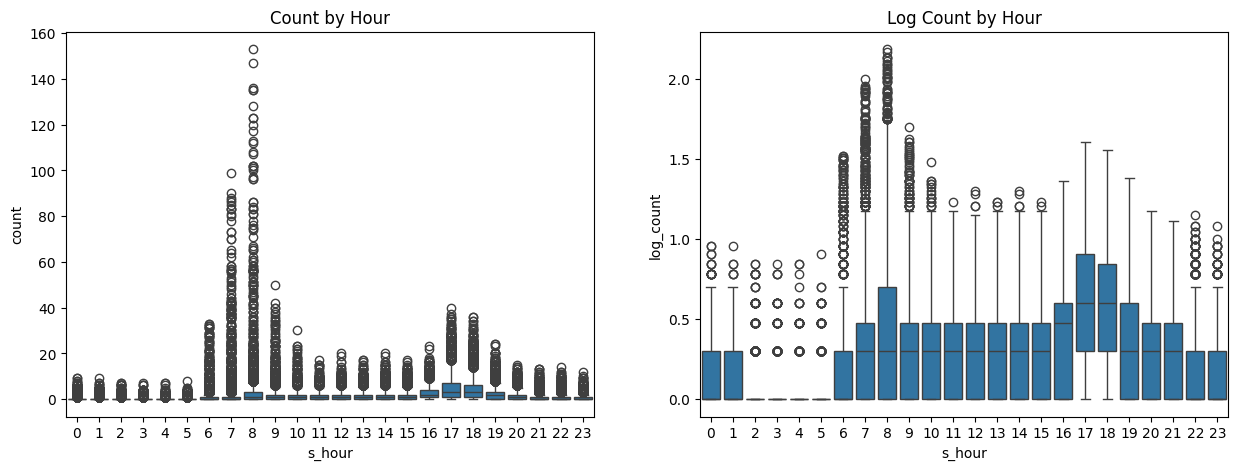

In [16]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(x='s_hour', y='count', data=df, ax=ax[0])
ax[0].set_title('Count by Hour')

sns.boxplot(x='s_hour', y='log_count', data=df, ax=ax[1])
ax[1].set_title('Log Count by Hour')
plt.show()


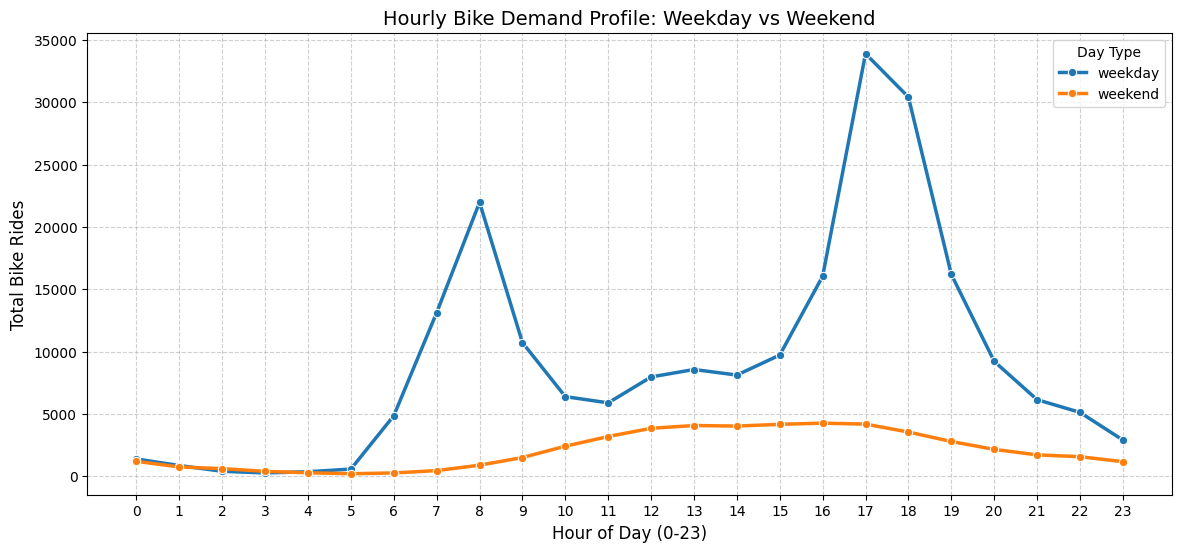

In [17]:
hourly_trend = df.groupby(['s_hour', 'weekend_or_weekday_sdate'])['count'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=hourly_trend, x='s_hour', y='count', hue='weekend_or_weekday_sdate', marker='o', linewidth=2.5)
plt.title('Hourly Bike Demand Profile: Weekday vs Weekend', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Total Bike Rides', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Day Type')
plt.show()

### Correlation

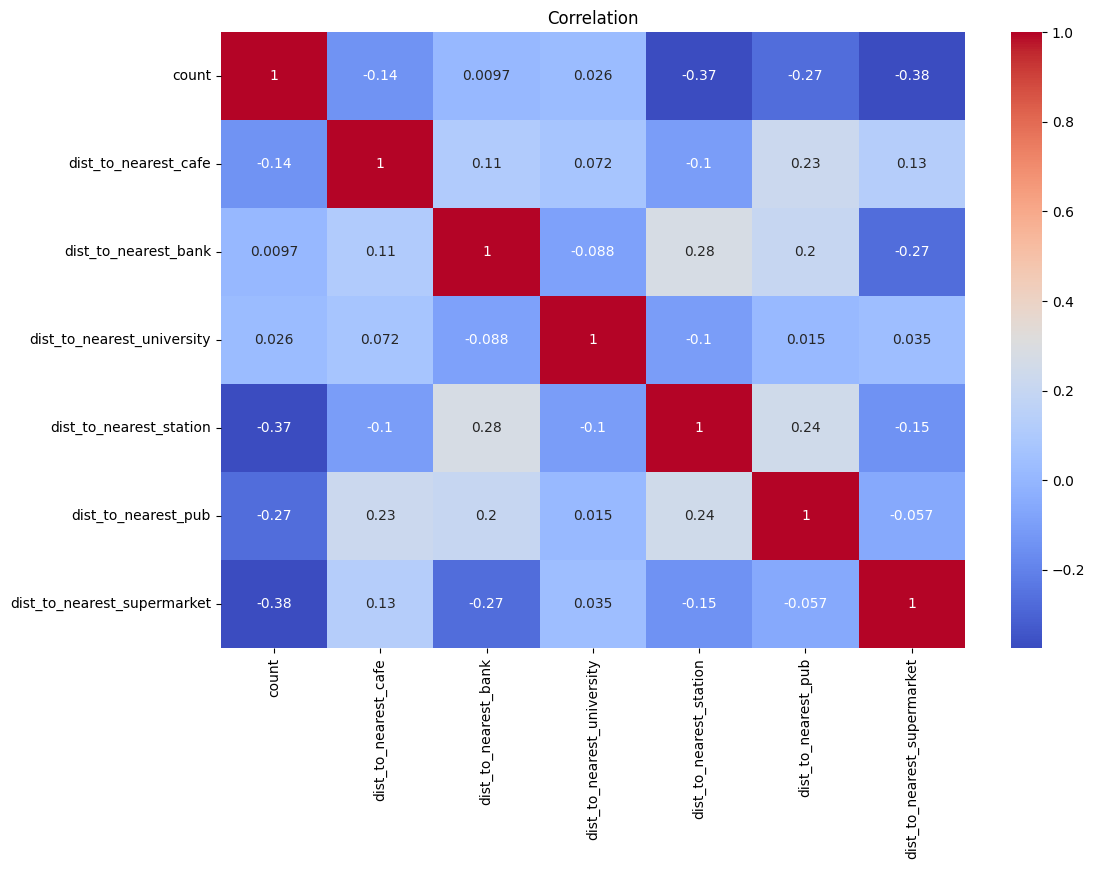

In [18]:
features = [
    'dist_to_nearest_cafe', 'dist_to_nearest_bank', 'dist_to_nearest_university',
    'dist_to_nearest_station', 'dist_to_nearest_pub', 'dist_to_nearest_supermarket'
]

agg_dict = {
    "count": "sum",
    "dist_to_nearest_cafe": "first",
    "dist_to_nearest_bank": "first",
    "dist_to_nearest_university": "first",
    "dist_to_nearest_station": "first",
    "dist_to_nearest_pub": "first",
    "dist_to_nearest_supermarket": "first"
}




temp_df = df[features + ['count'] + ['start_station_number']].groupby("start_station_number").agg(agg_dict).reset_index().drop(axis=1, columns=["start_station_number"])

plt.figure(figsize=(12,8))
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation")

plt.show()



### Distribution Of Amenity Densities

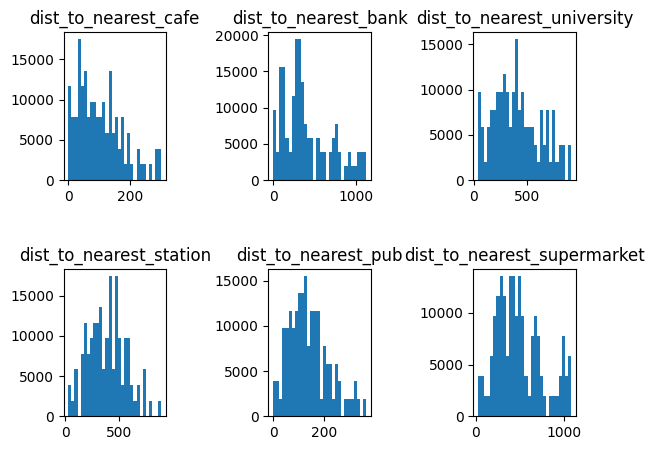

In [19]:


figure, axis = plt.subplots(2, 3)
axis[0, 0].hist(df["dist_to_nearest_cafe"], bins=30)
axis[0, 0].set_title("dist_to_nearest_cafe")

axis[0, 1].hist(df["dist_to_nearest_bank"], bins=30)
axis[0, 1].set_title("dist_to_nearest_bank")

axis[0, 2].hist(df["dist_to_nearest_university"], bins=30)
axis[0, 2].set_title("dist_to_nearest_university")

axis[1, 0].hist(df["dist_to_nearest_station"], bins=30)
axis[1, 0].set_title("dist_to_nearest_station")

axis[1, 1].hist(df["dist_to_nearest_pub"], bins=30)
axis[1, 1].set_title("dist_to_nearest_pub")

axis[1, 2].hist(df["dist_to_nearest_supermarket"], bins=30)
axis[1, 2].set_title("dist_to_nearest_supermarket")

plt.subplots_adjust(
    left=0.1,    # The left side of the subplots of the figure
    right=0.9,   # The right side of the subplots of the figure
    bottom=0.1,  # The bottom of the subplots of the figure
    top=0.9,     # The top of the subplots of the figure
    wspace=1,  # The amount of width reserved for blank space between subplots
    hspace=0.6   # The amount of height reserved for white space between subplots
)

plt.show()



In [20]:
# !pip install folium (if not already installed)
import folium
import numpy as np

target_lon = -0.09844180843941625
target_lat = 51.51370562455308

# Aggregate total counts and get unique coordinates per station
station_map_df = df.groupby(['start_station_number', 'latitude', 'longitude'])['count'].sum().reset_index()

# Initialize the map centered around London
london_map = folium.Map(location=[target_lat, target_lon], zoom_start=13, tiles='cartodbpositron')

folium.CircleMarker(
        location=[target_lat, target_lon],
        color='#b43d1f',
        popup="Reference Coordinate",
        fill=True,
        fill_color="#b43d1f",
        fill_opacity=1,
        weight=1
    ).add_to(london_map)

# Add scaled circle markers for each station
for idx, row in station_map_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        # Scale the radius logarithmically so highly used stations don't cover the entire map
        radius=np.log1p(row['count']) * 1.5,
        popup=f"Station ID: {row['start_station_number']}<br>Total Rides: {row['count']}",
        tooltip=f"Station {row['start_station_number']}",
        color='#1f77b4',
        fill=True,
        fill_color='#1f77b4',
        fill_opacity=0.6,
        weight=1
    ).add_to(london_map)

# Display the map in the notebook
london_map

C:\Users\USER\AppData\Local\Temp\ipykernel_15780\3396930615.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_stations, x='count', y='start_station_number', palette='viridis')


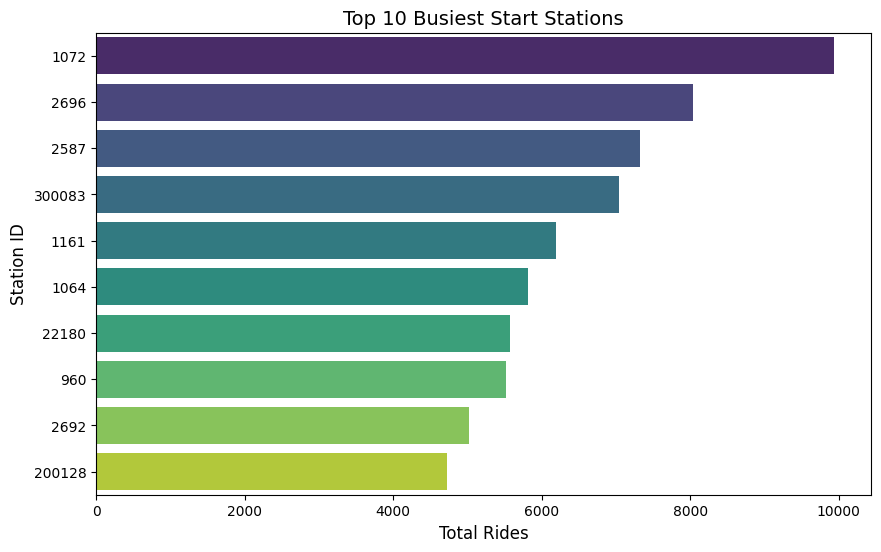

In [21]:
top_stations = df.groupby('start_station_number')['count'].sum().sort_values(ascending=False).head(10).reset_index()
# Convert to string to treat station numbers as categorical labels
top_stations['start_station_number'] = top_stations['start_station_number'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_stations, x='count', y='start_station_number', palette='viridis')
plt.title('Top 10 Busiest Start Stations', fontsize=14)
plt.xlabel('Total Rides', fontsize=12)
plt.ylabel('Station ID', fontsize=12)
plt.show()